<a href="https://colab.research.google.com/github/AgrimaOjha/HydraSol-ML/blob/main/HydraSol_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HydraSol** **ML**

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

### Load Dataset

In [29]:
df=pd.read_csv('delaney_solubility_with_descriptors.csv')
df


,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


### Data preprocessing

In [6]:
y = df['logS']
X = df.drop('logS', axis=1)

In [7]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [8]:
X_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
107,3.14280,112.216,5.0,0.000000
378,-2.07850,142.070,0.0,0.000000
529,-0.47730,168.152,0.0,0.000000
546,-0.86740,154.125,0.0,0.000000
320,1.62150,100.161,2.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [9]:
X_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
822,2.91000,172.268,7.0,0.000000
118,7.27400,360.882,1.0,0.666667
347,1.94040,145.161,0.0,0.909091
1123,1.98640,119.378,0.0,0.000000
924,1.70062,108.140,0.0,0.750000
...,...,...,...,...
1114,1.76210,478.513,4.0,0.000000
427,6.32820,276.338,0.0,1.000000
711,0.04430,218.205,5.0,0.000000
4,2.91890,187.375,1.0,0.000000


### Model Training

In [10]:
#Linear Regression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred=model.predict(X_test)

In [12]:
y_pred

array([-3.05722870e+00, -7.77785827e+00, -2.55016650e+00, -2.01523582e+00,
       -2.06375990e+00, -9.99672215e-01, -5.94603364e-01, -5.53626003e-01,
       -5.72200956e+00, -3.94006681e+00, -3.95496755e+00, -2.29737009e+00,
       -1.48980354e+00, -1.48988982e+00, -4.64510806e+00, -1.90396018e+00,
       -1.51566313e+00, -3.16424605e+00, -3.70863920e+00, -5.58105660e+00,
       -3.25038467e+00, -5.04235077e+00, -5.69194881e+00, -2.14339849e+00,
       -4.35689341e+00, -5.03964756e+00, -3.10383618e+00, -4.40286964e+00,
       -4.21276272e+00,  5.56508349e-01, -1.45537678e+00, -4.41027396e+00,
       -2.59668773e+00, -1.53336276e+00, -5.55749874e-01, -1.67111795e+00,
       -2.78163675e+00, -3.15395565e+00, -5.27083361e+00, -1.75321446e+00,
       -1.53350725e+00, -2.01255666e+00, -6.57559167e+00, -7.89433046e+00,
       -5.76437127e+00, -4.16422068e+00, -3.43694663e+00,  1.43834212e+00,
       -1.12679105e-02, -2.34521849e+00, -1.86480046e+00, -5.03964756e+00,
        8.55886378e-01, -

In [13]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [14]:
print('LR MSE:',mse)
print('LR R2:',r2)

LR MSE: 1.0206953660861033
LR R2: 0.7891616188563282


In [15]:
lr_results = pd.DataFrame(['Linear regression', mse, r2]).transpose()
lr_results.columns = ['Method','Test MSE', 'Test R2']

In [16]:
lr_results

,Method,Test MSE,Test R2
0,Linear regression,1.020695,0.789162


In [19]:
#Random Forest
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [20]:
y_rf_pred = rf.predict(X_test)

In [21]:
rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test, y_rf_pred)

In [22]:
rf_results = pd.DataFrame(['Random forest', rf_mse, rf_r2]).transpose()
rf_results.columns = ['Method','Test MSE', 'Test R2']
rf_results

,Method,Test MSE,Test R2
0,Random forest,1.407688,0.709223


In [24]:
df_models = pd.concat([lr_results, rf_results], axis=0)

In [25]:
df_models.reset_index(drop=True)

,Method,Test MSE,Test R2
0,Linear regression,1.020695,0.789162
1,Random forest,1.407688,0.709223


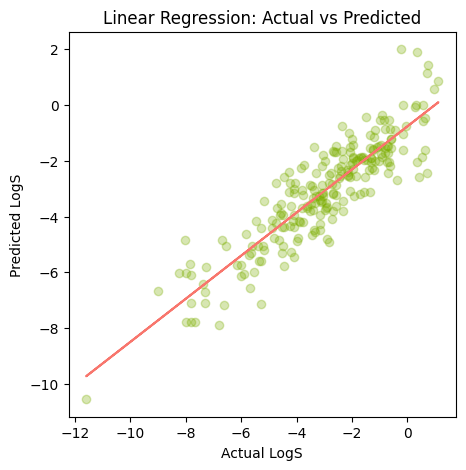

In [28]:
plt.figure(figsize=(5,5))


plt.scatter(x=y_test, y=y_pred, c="#7CAE00", alpha=0.3)


z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)

plt.plot(y_test, p(y_test), '#F8766D')

plt.ylabel('Predicted LogS')
plt.xlabel('Actual LogS')
plt.title('Linear Regression: Actual vs Predicted')

plt.show()